In [17]:
import numpy as np
import matplotlib.pyplot as plt
%run Poisson2D.ipynb
%run Cycle.ipynb

In [27]:
p=6
n=2**p - 1
#Build Poisson matrix
A = Poisson2D(n)
# Random right-hand side
np.random.seed(25345416)
f=np.random.rand(n * n)
# Initial guess is all 0
u = np.zeros(n * n)
# Build multigrid hierarchy
A_list, R_list, P_list = build_multigrid_hierarchy(A, n, direct_size=49)
num_cycles = 10
residual_norms = []
r = f - A @ u
residual_norms.append(np.linalg.norm(r))
for k in range(1, num_cycles + 1):
# Apply one V-cycle
    u = v_cycle(level=0,A_list=A_list,R_list=R_list,   P_list=P_list, b=f,x=u,omega=2/3, pre_smooth=3, post_smooth=3)
    # Compute residual after this V-cycle
    r = f - A @ u
    residual_norm = np.linalg.norm(r)
    residual_norms.append(residual_norm)

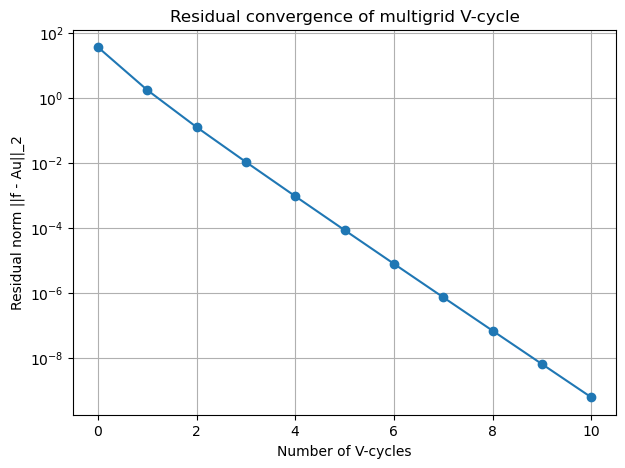

<Figure size 640x480 with 0 Axes>

In [32]:
plt.figure(figsize=(7, 5))
plt.semilogy(range(num_cycles + 1), residual_norms, marker="o")
plt.xlabel("Number of V-cycles")
plt.ylabel("Residual norm ||f - Au||_2")
plt.title("Residual convergence of multigrid V-cycle")
plt.grid(True, which="both")
plt.show()
plt.savefig("residual_convergence.png", dpi=300, bbox_inches="tight")

The residual norm decreases as the number of V-cycles increases. This shows that the multigrid V-cycle is working correctly for the randomly generated right hand side. The plot uses a logarithmic scale for the residual norm, so a nearly straight decreasing line means that the convergence is exponential. Since the residual is reduced within fewerthan 15 V-cycles, the result is consistent with the expected behaviour of a multigrid solver.